# **과제2_이변량분석**

* 카시트에 대해서 지역 매장 별 매출액을 분석하고자 합니다.

![](https://cdn.images.express.co.uk/img/dynamic/24/590x/child-car-seat-986556.jpg?r=1532946857754)

## **1.환경준비**

### **(1) 라이브러리 로딩**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as spst

### **(2) 데이터 로딩**

|	변수명	|	설명	|	구분	|
|----|----|----|
|	Sales 	|	 각 지역 판매량(단위 : 1000개)	|	Target(Y)	|
|	CompPrice 	|	지역별 경쟁사 판매가격(달러)	|	feature	|
|	Advertising 	|	 각 지역, 회사의 광고 예산(단위 : 1000달러)	|	feature	|
|	Population 	|	 지역 인구수(단위 : 1000명)	|	feature	|
|	Price 	|	 자사 지역별 판매가격(달러)	|	feature	|
|	ShelveLoc 	|	 진열상태	|	feature	|
|	Age 	|	 지역 인구의 평균 연령	|	feature	|
|	US 	|	 매장이 미국에 있는지 여부	|	feature	|
|	Income 	|	 지역 주민 평균 소득	|	feature	|
|	Urban 	|	 매장이 도시에 있는지 여부	|	feature	|



In [2]:
path = 'https://raw.githubusercontent.com/DA4BAM/dataset/master/Carseats2.csv'
data = pd.read_csv(path)
data.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Urban,US
0,9.50,138,73,11,276,120,Bad,42,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,Yes,No


In [3]:
target = 'Sales'

In [ ]:
data.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Urban', 'US'],
      dtype='object')

## **2.숫자형 X --> Y**

* 모든 숫자형 X에 대해서 Y와 비교하여 차트를 그리고 수치화 하시오.
> ① 시각화 : scatter, jointplot  
> ② 수치화 : 상관분석
* 데이터를 분석하면서, 추가 분석할 만한 사항이 있는지 살펴보고 시도해보세요.

### **(1) Advertising -> Sales**

① 시각화 : scatter(혹은 regplot, jointplot)

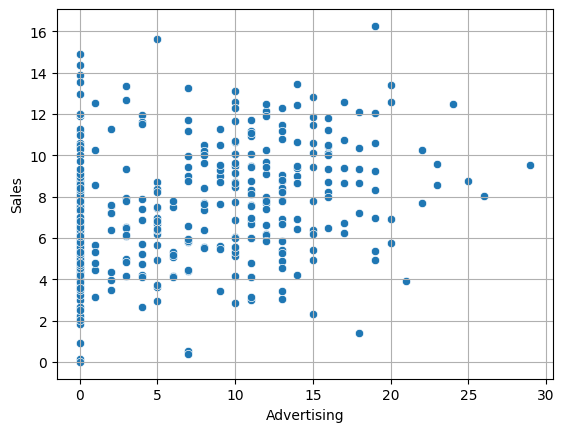

In [ ]:
sns.scatterplot(x='Advertising', y=target, data = data)
plt.grid()
plt.show()

② 수치화 : 상관분석

In [ ]:
spst.pearsonr(data['Advertising'], data['Sales'])

PearsonRResult(statistic=np.float64(0.2695067813769019), pvalue=np.float64(4.377677110302841e-08))

③ 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

In [ ]:
# 산점도에서는 어떠한 패턴도 파악할 수 없으며, 갈수록 중앙에 가까워지는 기이한 그래프를 보여준다. 따라서 직선을 그리기가 힘들다고 판단할 수 있다.
# 상관계수로 파악할 때, 약 0.27로 상관관계가 없다고 말할 수 있는 수준의 값이다. 그러나 p-value는 0에 꽤나 가까운 값을 보여주어, 상관관계가 아예 없다고는 할 수 없다.
# 이로써 광고 예산은 판매량에 영향을 거의 주지 않지만, 아예 영향이 없다고는 할 수 없다.
# 다만 많은 이상치로 인해 강한 상관관계가 있다고 말 할 수는 없으며, 다른 수치형 변수와 Sales 변수와의 관계를 파악해봐야 한다.
# 더 강한 상관관계가 가진 변수가 있다면, 그 변수가 Sales에 가장 강한 영향을 미치는 변수라고 할 수 있다.

### **(2) Population -> Sales**

① 시각화 : scatter(혹은 regplot, jointplot)

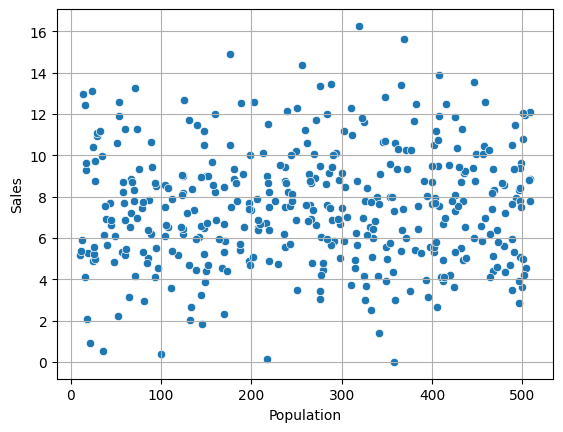

In [ ]:
sns.scatterplot(x='Population', y=target, data = data)
plt.grid()
plt.show()

② 수치화 : 상관분석

In [ ]:
spst.pearsonr(data['Population'], data['Sales'])

PearsonRResult(statistic=np.float64(0.050470984472039196), pvalue=np.float64(0.31398160931904745))

③ 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

In [ ]:
# 산점도에서는 그래프가 그려지는 사각형 안에서 고루 퍼져있는 형태로, 상관관계가 없는 변수들의 전형적인 그래프를 보여주고 있다.
# 상관계수도 약 0.05로 0에 가깝고, p-value도 약 0.3으로 유의수준인 0.05를 훌쩍 넘어 수치 상으로도 상관관계가 없는 것을 파악할 수 있다.
# 이로써 각 지역의 인구수는 판매량에 전혀 영향을 미치지 못하는 것으로 분석할 수 있다.

### **(3) Price -> Sales**

① 시각화 : scatter(혹은 regplot, jointplot)

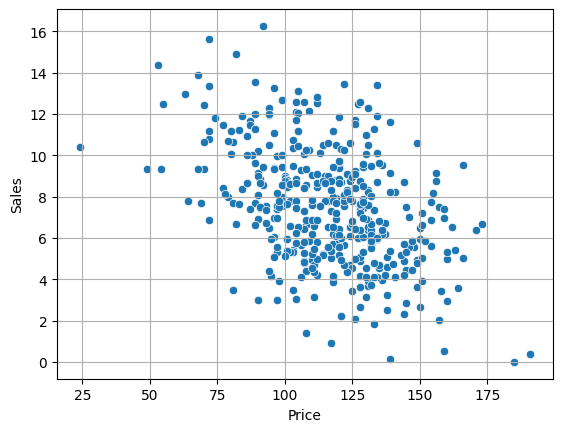

In [ ]:
sns.scatterplot(x='Price', y=target, data = data)
plt.grid()
plt.show()

② 수치화 : 상관분석

In [ ]:
spst.pearsonr(data['Price'], data['Sales'])

PearsonRResult(statistic=np.float64(-0.4449507278465727), pvalue=np.float64(7.618187011912776e-21))

③ 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

In [ ]:
# 산점도를 보았을 때, 우하향 하는 그래프를 그릴 수 있지만 각 지역의 가격 간에 판매량이 겹치는 부분이 많아서 이상치가 꽤 존재하는 것으로 파악된다.
# 상관계수를 보면 약 -0.44로 중간 정도의 상관관계를 가지고 있는 것으로 보이고, p-value도 0에 가까워 이를 뒷받침 해준다.
# 따라서 판매 가격은 판매량에 중간 정도의 영향을 준다고 분석이 가능하다.
# 다만 이상치가 꽤나 존재하는 것으로 파악 되기 때문에 강한 상관관계는 아닌 것으로 보여, 다른 변수와의 상관관계를 더 파악해봐야 할 것 같다.

### **(4) Age -> Sales**

① 시각화 : scatter(혹은 regplot, jointplot)

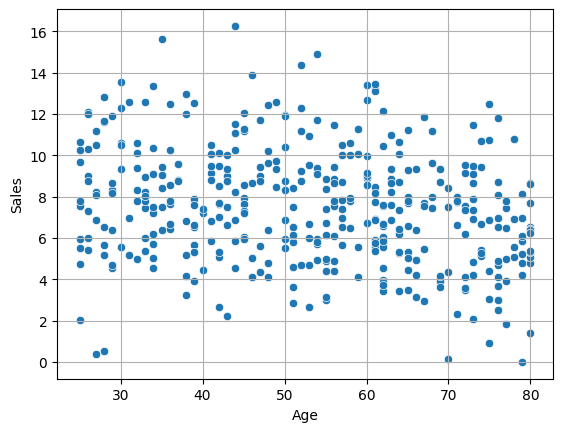

In [ ]:
sns.scatterplot(x='Age', y=target, data = data)
plt.grid()
plt.show()

② 수치화 : 상관분석

In [ ]:
spst.pearsonr(data['Age'], data['Sales'])

PearsonRResult(statistic=np.float64(-0.23181543960457646), pvalue=np.float64(2.78894983937141e-06))

③ 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

In [ ]:
# 산점도를 보면 각 나이대별로 판매량이 다양한 것을 볼 수 있다. 이로써 직선 패턴을 그린다고 해도, 그 직선에서 벗어나는 이상치가 많을 것으로 보인다.
# 상관계수로 파악하면 약 -0.23으로 상관관계가 거의 없는 것으로 파악되며,
# p-value도 0에 가깝긴 하지만 다른 변수들보다는 비교적 높은 값을 보여주어 큰 상관관계는 없는것으로 보인다.
# 따라서 평균 연령은 판매량에 큰 영향을 미치지 않으며, 사실상 관계가 없다고 분석할 수 있다.

### **(5) CompPrice -> Sales**

① 시각화 : scatter(혹은 regplot, jointplot)

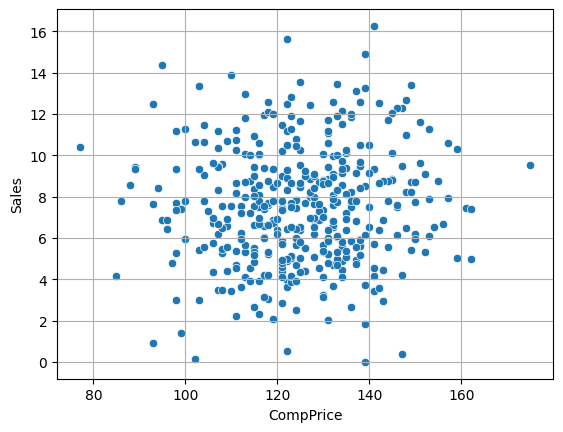

In [ ]:
sns.scatterplot(x='CompPrice', y=target, data = data)
plt.grid()
plt.show()

② 수치화 : 상관분석

In [ ]:
spst.pearsonr(data['CompPrice'], data['Sales'])

PearsonRResult(statistic=np.float64(0.06407872955062152), pvalue=np.float64(0.20093982894184073))

③ 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

In [ ]:
# 산점도에서 특이한 공 모양의 그래프를 볼 수 있으며, 사실상 직선의 모양은 거의 그려지지 않는 것으로 파악된다.
# 상관계수를 보면 약 0.06, p-value는 약 0.2로 상관관계가 없는 전형적인 수치를 보여준다.
# 이로써 경쟁사 판매가격은 판매량에 전혀 영향을 미치지 않는 것으로 분석이 가능하다.

# 다만 상식적으로 생각해봤을 때, 경쟁사 판매가격은 판매량보다 자사 판매가격에 영향을 많이 미칠 것으로 보인다.
# 그러나 자사 판매가격은 판매량에 어느정도 영향을 미치는 것으로 파악이 되었기 때문에,
# 그 세 변수 간의 관계를 추가로 분석을 진행해보면 또 다른 결과를 보여줄 수 있을 것으로 보여진다.

* 추가분석 : 가격 경쟁력 ( Price_Diff = CompPrice - Price)

In [4]:
data['Price_Diff'] = data['CompPrice'] - data['Price']
data.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Urban,US,Price_Diff
0,9.50,138,73,11,276,120,Bad,42,Yes,Yes,18
1,11.22,111,48,16,260,83,Good,65,Yes,Yes,28
2,10.06,113,35,10,269,80,Medium,59,Yes,Yes,33
3,7.40,117,100,4,466,97,Medium,55,Yes,Yes,20
4,4.15,141,64,3,340,128,Bad,38,Yes,No,13


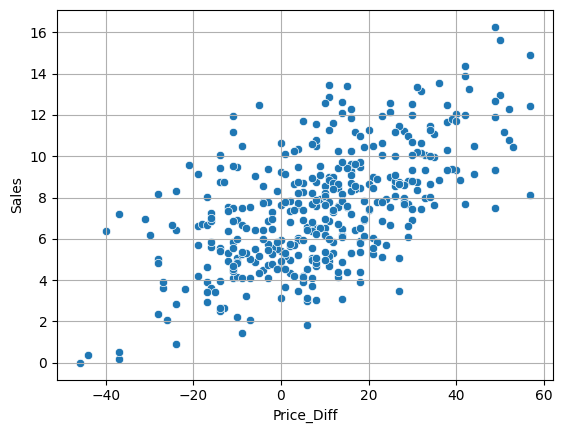

In [5]:
sns.scatterplot(x='Price_Diff', y=target, data = data)
plt.grid()
plt.show()

In [6]:
spst.pearsonr(data['Price_Diff'], data['Sales'])

PearsonRResult(statistic=np.float64(0.5979217124533923), pvalue=np.float64(3.877120641788745e-40))

### **(6) Income -> Sales**

① 시각화 : scatter(혹은 regplot, jointplot)

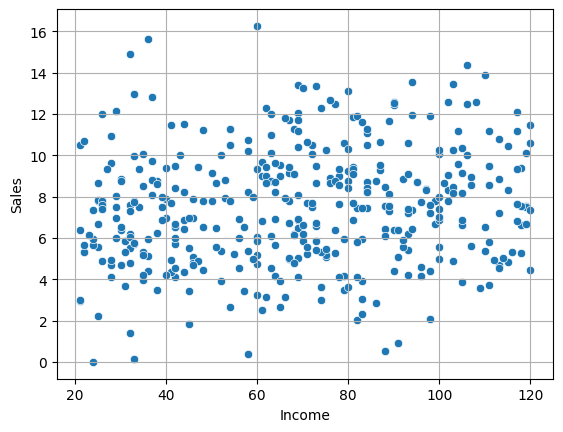

In [ ]:
sns.scatterplot(x='Income', y=target, data = data)
plt.grid()
plt.show()

② 수치화 : 상관분석

In [ ]:
spst.pearsonr(data['Income'], data['Sales'])

PearsonRResult(statistic=np.float64(0.15195097946754427), pvalue=np.float64(0.002309670453951793))

③ 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

In [ ]:
# 지역 주민 평균 소득이 높을 수록 소비가 많아질 것이라는 상식적인 전제를 바탕으로 분석을 진행했을 때 놀라운 결과를 보여주었다.

# 산점도에서는 평균 소득 구간 별로 다양한 판매량을 보여주었고, 예상과는 다르게 직선의 그래프를 그리기 힘들었다.
# 상관계수는 약 0.15로 아주 작은 값을, p-value는 약 0.002로 유의수준 보다는 낮지만 여전히 큰 상관 관계는 없는 것으로 분석을 할 수 있다.
# 따라서 평균 소득은 판매량에 영향을 거의 미치지 못하는 것으로 파악된다.

# 그렇다면 평균 소득과 판매 가격의 상관관계는 어떻게 될까 라는 의문이 생긴다.
# 상식적인 회사라면 평균 소득이 많은 지역에는 금전적으로 여유로운 사람들이 많기 때문에 같은 상품을 비싸게 책정할 가능성이 높기 때문이다.
# 이를 통해 판매 가격과 평균 소득으로 또 다른 결과를 도출해낼 수 있을지에 대해 추가 분석을 진행해볼 수 있을 것이다.

## **3.범주형 X --> Y**

* 모든 범주형 X에 대해서 Y와 비교하여 차트를 그리고 수치화 하시오.
>   ① 시각화 : 평균비교 barplot  
>   ② 수치화 : t-test, anova

* 데이터를 분석하면서, 추가 분석할 만한 사항이 있는지 살펴보고 시도해보세요.

### **(1) ShelveLoc-> Sales**

① 시각화 : 평균비교 barplot

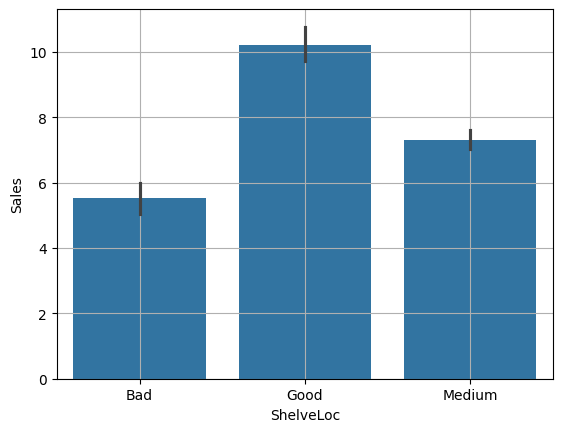

In [ ]:
sns.barplot(x="ShelveLoc", y=target, data=data)
plt.grid()
plt.show()

② 수치화 : t-test, anova

In [ ]:
# 집단이 여러개이므로 ANOVA 수행

print(data['ShelveLoc'].unique())

Bad = data.loc[data['ShelveLoc']=='Bad', target]
Medium = data.loc[data['ShelveLoc']=='Medium', target]
Good = data.loc[data['ShelveLoc']=='Good', target]

print(spst.f_oneway(Bad, Medium, Good))

['Bad' 'Good' 'Medium']
F_onewayResult(statistic=np.float64(92.22990509910348), pvalue=np.float64(1.26693609015938e-33))


③ 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

In [ ]:
# 가설로 '진열 상태와 판매량에는 관계가 없다.'를 세운 뒤에 가설 검정을 진행해본다.

# bar plot을 보면, 각 집단마다 신뢰구간이 전혀 겹치지 않고 범주에 따라 꽤나 차이를 보여주고 있다.
# ANOVA 수행 결과 p-value가 거의 0에 가깝고, F값이 약 92로 아주 크게 나와 귀무가설을 기각할 수 있다.
# 따라서 진열 상태와 판매량에는 관계가 있고, 진열 상태가 어떤지에 따라 판매량이 크게 변화하는 것으로 분석이 가능하다.
# bar plot에서는 진열 상태가 좋을 수록 판매량이 많아지는 것을 보여주고 있다.

### **(2) Urban -> Sales**

① 시각화 : 평균비교 barplot

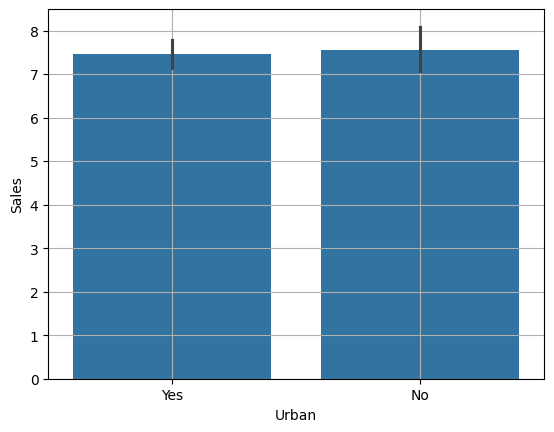

In [ ]:
sns.barplot(x="Urban", y=target, data=data)
plt.grid()
plt.show()

② 수치화 : t-test, anova

In [ ]:
# 집단이 두개이므로 two-sample t-test 수행

print(data['Urban'].unique())

urb = data.loc[data['Urban']=='Yes', target]
side = data.loc[data['Urban']=='No', target]

print(spst.ttest_ind(urb, side))

['Yes' 'No']
TtestResult(statistic=np.float64(-0.30765346670661126), pvalue=np.float64(0.7585069603942775), df=np.float64(398.0))


③ 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

In [ ]:
# 가설로 '매장의 위치(도시)와 판매량에는 관계가 없다.'를 세운 뒤에 가설 검정을 진행해본다.

# 그래프를 보면, 신뢰구간이 꽤나 많이 겹쳐있는 것을 볼 수 있다.
# 게다가 t-test 수행 결과 p-value가 약 0.76로 큰 수가 나오므로, 귀무가설을 기각할 수 없다.
# 따라서 매장이 도시에 있는 것과 판매량에는 관계가 없는 것으로 분석할 수 있다.

### **(3) US-> Sales**

① 시각화 : 평균비교 barplot

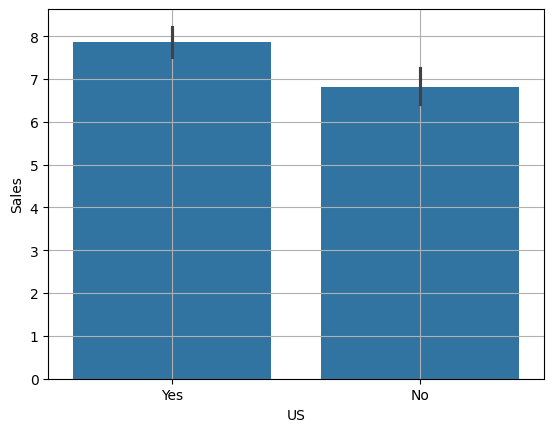

In [ ]:
sns.barplot(x="US", y=target, data=data)
plt.grid()
plt.show()

② 수치화 : t-test, anova

In [ ]:
# 집단이 두개이므로 two-sample t-test 수행

print(data['US'].unique())

us = data.loc[data['US']=='Yes', target]
usn = data.loc[data['US']=='No', target]

print(spst.ttest_ind(us, usn))

['Yes' 'No']
TtestResult(statistic=np.float64(3.589738747802499), pvalue=np.float64(0.00037233958701471517), df=np.float64(398.0))


③ 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

In [ ]:
# 가설로 '매장의 위치(미국)와 판매량에는 관계가 없다.'를 세운 뒤에 가설 검정을 진행해본다.

# 그래프를 그렸을 때, 신뢰구간이 서로 근접하기는 했지만, 겹치지는 않는 것으로 보여진다.
# 그리고 t-test 수행 결과 p-value가 약 0.0004로 유의수준인 0.05보다는 작은 수가 나오므로, 귀무 가설을 기각할 수는 있다.
# 따라서 매장이 미국에 위치해 있는 것과 판매량에는 어느 정도 상관 관계가 있는 것으로 파악할 수 있다.
# 그러나 유의 수준과 p-value 사이에 큰 차이를 보이고 있지 않기 때문에 강한 상관 관계가 있는 것으로 파악되지는 않는다.

## **4.관계 정리하기**

In [ ]:
datanum = data[['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age']]
datanum.corr()

,Sales,CompPrice,Income,Advertising,Population,Price,Age
Sales,1.000000,0.064079,0.151951,0.269507,0.050471,-0.444951,-0.231815
CompPrice,0.064079,1.000000,-0.080653,-0.024199,-0.094707,0.584848,-0.100239
Income,0.151951,-0.080653,1.000000,0.058995,-0.007877,-0.056698,-0.004670
Advertising,0.269507,-0.024199,0.058995,1.000000,0.265652,0.044537,-0.004557
Population,0.050471,-0.094707,-0.007877,0.265652,1.000000,-0.012144,-0.042663
Price,-0.444951,0.584848,-0.056698,0.044537,-0.012144,1.000000,-0.102177
Age,-0.231815,-0.100239,-0.004670,-0.004557,-0.042663,-0.102177,1.000000


① 강한관계

In [ ]:
# 수치형 변수에서는 target과 강한 상관관계를 가진 변수는 찾아볼 수 없었고,
# 범주형 변수에서 ShelveLoc 변수가 높은 F-statistic와 변수 중 가장 낮은 p-value로 꽤나 강한 관계를 보여주고 있다.

# 또한 수치형 변수간의 상관계수를 보았을 때, target은 아니지만 이전에 2-(5)에서 예측했던 대로 Price와 CompPrice의 상관계수가 높은 것으로 관측되며,
# 이는 자사 판매가격과 경쟁사 판매가격에는 강한 상관관계가 있는 것으로 보여진다.

② 중간관계

In [ ]:
# 수치형 변수에서는 Price 변수가 약 -0.44의 상관계수를 보여주며 target과 중간 정도의 상관 관계를 가지고 있는 것으로 분석된다.
# 또한 Advertising 변수와 Age 변수도 각각 0.27, -0.23의 상관계수와 유의수준보다 낮은 p-value 값으로 상관 관계가 있는 것으로 파악되었다.
# 사회 분야에서 그 정도의 상관계수면 거의 관계가 없는 것으로 파악되지만, p-value로 참작하여 중간(약한) 정도의 상관 관계가 있는 것으로 분석하였다.

# 범주형 변수에서는 US 변수가 p-value가 0.05보다 낮아 어느 정도의 상관 관계가 있는 것으로 보여졌는데,
# 큰 관계는 아닌 것으로 보아 중간관계에 포함 시킬 수 있다고 판단하였다.

③ 관계없음

In [ ]:
# 수치형 변수에서는 Population, CompPrice, Income 변수가 낮은 상관계수를 보여주며 target과 관계가 없는 것으로 분석되었다.
# 이 변수들 전부 0.2보다 낮은 상관계수를 보여주었으며, Income을 제외한 두 변수는 높은 p-value로 아예 관계가 없다는 것으로 파악되었다.
# Income 변수의 경우 유의수준보다 낮은 p-value인 0.002를 보여주기는 했지만, 약 0.15의 낮은 상관계수를 보여주어, 관계가 없는 것으로 분석하였다.

# 범주형 변수에서는 약 0.76이라는 아주 높은 p-value 를 가지고 있는 Urban 변수가 관계가 없는 것으로 분류되었다.
# F-statistic도 -0.3으로 아주 낮은 수를 보여주었기 때문에 귀무가설을 기각하지 못할 이유는 충분했기 때문이다.

# 결론

이로써 판매량과 강한 상관관계를 가진 변수는 그나마 p-value가 제일 낮았던 ShelveLoc을 제외하고는 딱히 분석되지 않았다.

따라서 판매량에 영향을 줄 수 있는 다른 수치형, 범주형 변수를 찾아 재분석하는 단계가 필요한 것으로 보인다.

예를 들면, 포장 비용이나 포장 디자인 설문(범주형), 혹은 만족도 등의 새로운 요인을 다시 설문을 통해 데이터를 얻은 뒤에 상관 분석을 진행하는 단계가 필요할 것 같다.